In [ ]:
'''
plot Figure 4
Jane 2026 Feb 
code snippet extracted and modified from 
5-2_ROI_RSA_python3-unique.py
'''

In [148]:
from os.path import join
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [149]:
# Directory
base_dir = '/backup/data/social_actions'
scripts_dir = join(base_dir, 'scripts')
data_dir = join(base_dir, 'fmri')
mvpa_dir = join(data_dir, 'pymvpa')

In [150]:
# Load pickle results
results = pickle.load(open(join(mvpa_dir, 'ROI_unique_12models.p'), 'rb')) 

In [151]:
rois = ['EV', 'LO', 'VT', 'pSTS', 'TPJ', 'PPC', 'AIP', 'VPM', 'PMC'] #glasser #reordered
hemis = ['lh', 'rh']

In [121]:
'''
plot_order = [
        'motion', 'gaze', 'nonverbs', 'verbs',
        'scene', 'person', 'object', 'sociality', 'transitivity',
        'body', 'people', 'category',
    ]
    roi = 'EV'
    # Build a tidy dataframe of means
    true_df = {'Unique ΔR²': [], 'hemisphere': [], 'model': []}
    for model_name in plot_order:
        for hemi in hemis:
            true_df['Unique ΔR²'].append(results[roi][hemi]['unique'][model_name]['mean'])
            true_df['model'].append(model_name)
            true_df['hemisphere'].append(hemi)
    true_df = pd.DataFrame(true_df)
    true_df['model'].replace('people', '$\\it{n}$ people', inplace= True)
'''

In [122]:
true_df

,Unique ΔR²,hemisphere,model
0,0.026677,lh,motion
1,0.045099,rh,motion
2,0.007365,lh,gaze
3,0.013027,rh,gaze
4,0.000226,lh,nonverbs
5,0.000424,rh,nonverbs
6,0.000115,lh,verbs
7,0.000259,rh,verbs
8,0.001092,lh,scene
9,0.000568,rh,scene


In [115]:
true_df

,Unique ΔR²,hemisphere,model
0,0.026677,lh,motion
1,0.045099,rh,motion
2,0.007365,lh,gaze
3,0.013027,rh,gaze
4,0.000226,lh,nonverbs
5,0.000424,rh,nonverbs
6,0.000115,lh,verbs
7,0.000259,rh,verbs
8,0.001092,lh,scene
9,0.000568,rh,scene


In [153]:
def plot_unique_tests(results, roi, save_fn=None, ax=None):
    plot_order = [
        'motion', 'gaze', 'nonverbs', 'verbs',
        'scene', 'person', 'object', 'sociality', 'transitivity',
        'body', 'people', 'category',
    ]
    
    # Build a tidy dataframe of means
    true_df = {'Unique ΔR²': [], 'hemisphere': [], 'model': []}
    for model_name in plot_order:
        for hemi in hemis:
            true_df['Unique ΔR²'].append(results[roi][hemi]['unique'][model_name]['mean'])
            true_df['model'].append(model_name)
            true_df['hemisphere'].append(hemi)
    true_df = pd.DataFrame(true_df)

    created_fig = False
    if ax is None:
        created_fig = True
        f, ax = plt.subplots(figsize=(4.5, 8))

    g = sns.pointplot(
        x='model', y='Unique ΔR²', data=true_df,
        hue='hemisphere', dodge=.37, join=False,
        order=plot_order, scale=0.5,
        palette=['darkblue', 'darkred'],
        ax=ax
    )
    
    g.set_xticklabels(['motion', 'gaze', 'nonverbs', 'verbs',
        'scene', 'person', 'object', 'sociality', 'transitivity',
        'body parts', '$\\it{n}$ people', 'category']) #updated mar 10

    plt.setp(ax.lines, zorder=1000000)
    plt.setp(ax.collections, zorder=1000000, label="", sizes=[30])
    
    # ---> UPDATED: Add reference lines here <---
    ax.axhline(y=0, linewidth=4, color='.75', linestyle='-', zorder=1)
    ax.axhline(y=0.02, linewidth=1, color='.85', linestyle='-', zorder=0)
    ax.axhline(y=0.04, linewidth=1, color='.85', linestyle='-', zorder=0)

    # Add participant-bootstrap CIs
    x_coords = []
    y_coords = []
    for point_pair in ax.collections:
        for x, y in point_pair.get_offsets():
            x_coords.append(x)
            y_coords.append(y)

    participants_errorbars = []
    y_i = 0
    for hemi in hemis:
        for model_name in plot_order:
            ci = results[roi][hemi]['unique'][model_name]['bootstrap_participants_ci']
            participants_errorbars.append([y_coords[y_i] - ci[0], ci[1] - y_coords[y_i]])
            y_i += 1
    participants_errorbars = np.array(participants_errorbars).T

    ax.errorbar(
        x_coords[:len(plot_order)], y_coords[:len(plot_order)],
        yerr=participants_errorbars[:, :len(plot_order)], fmt=' ',
        elinewidth=2.5, ecolor='darkblue'
    )
    ax.errorbar(
        x_coords[len(plot_order):], y_coords[len(plot_order):],
        yerr=participants_errorbars[:, len(plot_order):], fmt=' ',
        elinewidth=2.5, ecolor='darkred'
    )

    ax.set(ylabel='Unique variance (ΔR²)', title=roi)
    if ax.legend_ is not None:
        ax.legend_.remove()

    ax.tick_params(axis='x', rotation=90)
    
    if created_fig:
        plt.tight_layout()
        if save_fn:
            plt.savefig(save_fn + '.svg', format='svg', transparent=True)
            plt.savefig(save_fn + '.png', format='png', dpi=300, transparent=True)
        else:
            plt.show()
        plt.close()

In [103]:
#plot_unique_tests(results, rois, save_fn=None, ax=None)

In [154]:
def plot_all_rois_grid(results, rois, save_fn=None):
    # ---> UPDATED: Set sharey to 'row' <---
    fig, axes = plt.subplots(2, 5, figsize=(14, 10))#, sharey='row')
    axes = axes.flatten()

    n_panels = 10
    n_rois = len(rois)

    for i in range(n_panels):
        if i < n_rois:
            roi = rois[i]
            plot_unique_tests(results, roi, ax=axes[i])
            
            # ---> UPDATED: Remove y-labels for all except EV (index 0) and PPC (index 5) <---
            if i not in [0, 5]:
                axes[i].set_ylabel("")
                
            # ---> UPDATED: Set specific y-axis limits per row <---
            if i < 1:
                # Top row (EV)#, LO, VT, pSTS, TPJ)
                axes[i].set_ylim(-0.003, 0.06) #0.055) 
            else:
                # Bottom row (PPC, AIP, VPM, PMC)
                axes[i].axhline(y=0.01, linewidth=1, color='.85', linestyle='-', zorder=0)
                axes[i].set_ylim(-0.003, 0.03)#0.02)
                
        else:
            axes[i].axis('off')

    plt.tight_layout()
    if save_fn:
        plt.savefig(save_fn + '.svg', format='svg', transparent=True)
        plt.savefig(save_fn + '.png', format='png', dpi=300, transparent=True)
    else:
        plt.show()
    plt.close()

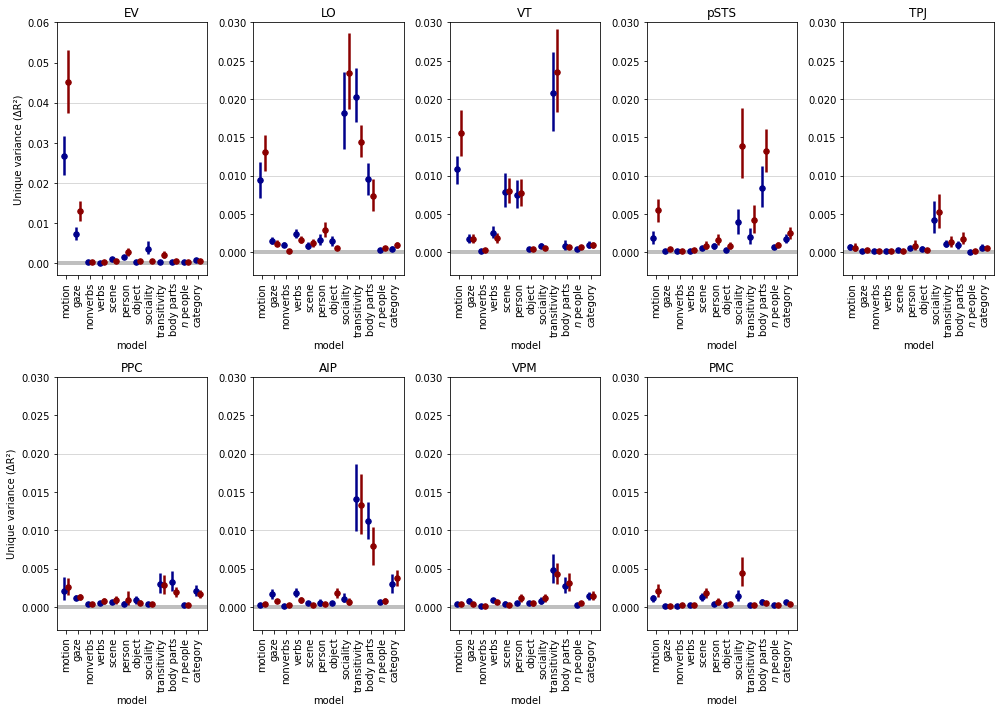

In [155]:
plot_all_rois_grid(results, rois)

In [156]:
plot_all_rois_grid(results, rois, save_fn='/backup/data/social_actions/figures/unique_roiGrid_12models')